In [1]:
from brian2 import *
import matplotlib.pyplot as plt

In [2]:
start_scope()

In [3]:
duration = 10 * second
dt_sim = 0.5 * ms

In [4]:
lambda_0 = 10 * Hz # Baseline intensity
alpha = 1.5 * Hz # Jump size
beta = 5.0 / second # Decay parameter

In [5]:
hawkes_eqs = '''
dh/dt = -beta * h : Hz  # Exponential decay of past event history
lambda_t = lambda_0 + h : Hz  # Total conditional intensity
'''

In [6]:
process = NeuronGroup(
    1, 
    model=hawkes_eqs, 
    threshold='rand() < lambda_t * dt', 
    reset='h += alpha', 
    dt=dt_sim,
    method='euler'
)

In [7]:
# Initialize the history component
process.h = 0.0 * Hz

In [8]:
state_mon = StateMonitor(process, ['lambda_t', 'h'], record=True)
spike_mon = SpikeMonitor(process)

In [9]:
run(duration)

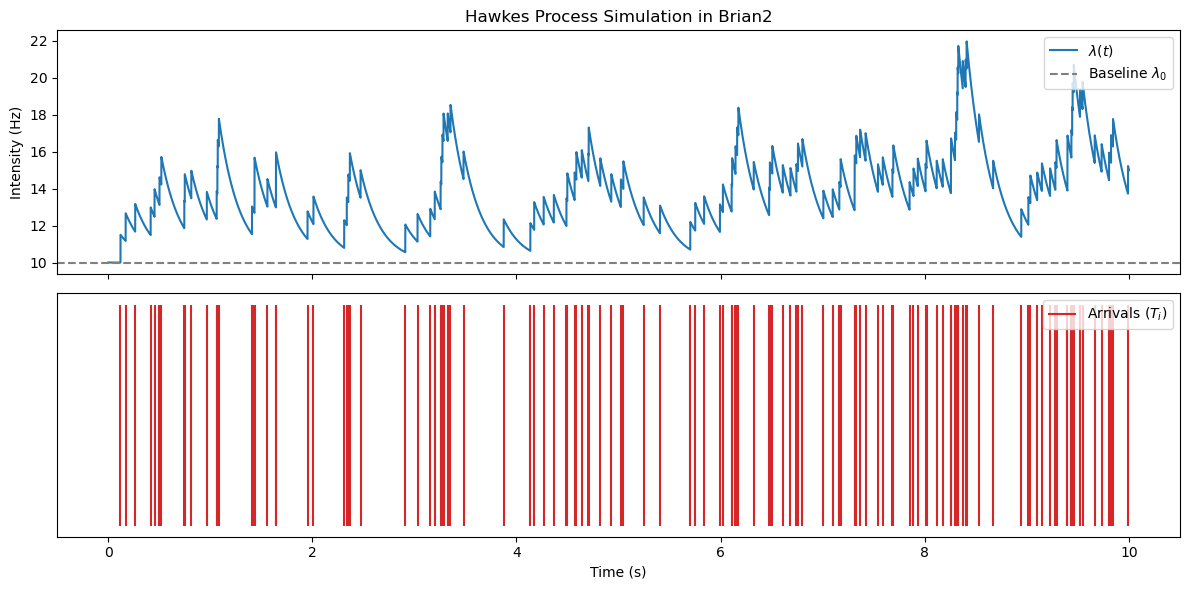

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Plot intensity over time
ax1.plot(state_mon.t/second, state_mon.lambda_t[0]/Hz, label=r'$\lambda(t)$', color='tab:blue')
ax1.axhline(lambda_0/Hz, color='gray', linestyle='--', label=r'Baseline $\lambda_0$')
ax1.set_ylabel('Intensity (Hz)')
ax1.legend(loc='upper right')
ax1.set_title('Hawkes Process Simulation in Brian2')

# Plot event arrivals (Spikes)
ax2.vlines(spike_mon.t/second, 0, 1, colors='tab:red', linestyles='-', linewidth=1.5, label='Arrivals ($T_i$)')
ax2.set_xlabel('Time (s)')
ax2.set_yticks([])
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [11]:
print(f"Total events triggered: {spike_mon.num_spikes}")

Total events triggered: 130
